# Compare a Blind-Rollout Candidate Image Against a Reference View

Verification notebook for `blind_visual_rollout_agent.py`'s reference-grounding step. Candidate images are already persisted on disk by `prepare_blind_candidates()` under `output/screenshots/blind_candidates/step_XXX/candidate_<id>.png` (nothing is deleted after an experiment). This notebook uses CLIP image embeddings (`GraphImageMatcher`) purely as an independent eyeballing/verification tool — the agent itself no longer uses image embeddings at all for reference grounding (that's LLM-judged now), so this is a separate sanity check, not a reflection of what the agent actually does.

Points at `reference_views_medical/skull/` — all 24 medical reference photos: 3 base views (`skull_001`=right, `skull_002`=front, `skull_003`=left lateral) x 8 in-plane rotations each (0/45/90/135/180/225/270/315 degrees).

Two things you can do here:
1. **Direct pairwise compare** — pick any two or three image paths (e.g. a candidate render and one or two reference photos, rotated or not) and see their exact CLIP cosine similarity side by side.
2. **Full top-k contact sheet** — pick a candidate image and see it ranked against all 24 reference images, so you can eyeball whether a CLIP-based match would agree with the LLM's own judgment.

In [6]:
import json
import sys, os
sys.path.insert(0, os.path.abspath('..'))

from itertools import combinations
from pathlib import Path
from IPython.display import Image, display

from camera_reasoning.camera_spatial_graph import CameraSpatialGraph
from camera_reasoning.image_view_matcher import GraphImageMatcher, save_contact_sheet

## Build/load the CLIP index (all 24 medical reference images)

`reference_views_medical/skull/` has no `camera_graph.json`/`CameraSpatialGraph` — it's a flat
`reference_views.json` of node_id -> description, 3 base views (`skull_001`=right,
`skull_002`=front, `skull_003`=left) x 8 in-plane rotations each (0/45/.../315 degrees) = 24
images total. This cell embeds all 24 (base + every rotated copy) — `GraphImageMatcher` only
needs a `.nodes` dict, so a lightweight stand-in is built instead of a real
`CameraSpatialGraph`. Loads from the cache if present and not stale (mtime-fingerprinted);
otherwise re-encodes all 24 images.

In [7]:
import types

_reference_entries = json.loads(open("../reference_views_medical/skull/reference_views.json").read())

# GraphImageMatcher only reads graph.nodes[node_id]["image_path"] — a plain
# SimpleNamespace stands in fine for the real CameraSpatialGraph it normally expects.
graph = types.SimpleNamespace(nodes={
    e["node_id"]: {"image_path": f"../reference_views_medical/skull/{e['node_id']}.png"}
    for e in _reference_entries
})

image_matcher = GraphImageMatcher(graph, cache_path="../reference_views_medical/skull/graph_embeddings.pkl")
image_matcher.build_index()

node_descriptions = {e["node_id"]: e["description"] for e in _reference_entries}
print(f"Loaded {len(graph.nodes)} medical reference images (base + rotated): {list(graph.nodes)}")

[image_view_matcher] Loaded 24 cached graph-node embeddings from ../reference_views_medical/skull/graph_embeddings.pkl
Loaded 24 medical reference images (base + rotated): ['skull_001', 'skull_001_rot045', 'skull_001_rot090', 'skull_001_rot135', 'skull_001_rot180', 'skull_001_rot225', 'skull_001_rot270', 'skull_001_rot315', 'skull_002', 'skull_002_rot045', 'skull_002_rot090', 'skull_002_rot135', 'skull_002_rot180', 'skull_002_rot225', 'skull_002_rot270', 'skull_002_rot315', 'skull_003', 'skull_003_rot045', 'skull_003_rot090', 'skull_003_rot135', 'skull_003_rot180', 'skull_003_rot225', 'skull_003_rot270', 'skull_003_rot315']


## Browse stored candidate images

Lists every `step_XXX` folder and the candidate image filenames inside it, most recent first. Copy a path from here into the cells below.

In [ ]:
candidates_root = Path("../output/screenshots/blind_candidates")
step_dirs = sorted(candidates_root.glob("step_*"), key=lambda p: p.stat().st_mtime, reverse=True)

for step_dir in step_dirs[:5]:
    print(step_dir)
    for img_path in sorted(step_dir.glob("candidate_*.png")):
        print(" ", img_path)

## 1. Direct pairwise compare (up to 3 images)

Set `IMAGE_A`/`IMAGE_B`/`IMAGE_C` (e.g. two candidate renders and a reference view, or any mix) and re-run. Prints the exact cosine similarity `_compute_reference_grounding_via_embeddings` would have used for every pair, and displays all three images so you can eyeball them. Leave `IMAGE_C = None` to fall back to a plain 2-image compare.

In [ ]:
IMAGE_A = "../output/screenshots/blind_candidates/step_009/candidate_0qhlt.png"
IMAGE_B = "../reference_views_medical/skull/skull_003.png"
IMAGE_C = "../reference_views_medical/skull/skull_003_rot090.png"  # set to None to compare only A/B

labeled_paths = [("A", IMAGE_A), ("B", IMAGE_B)]
if IMAGE_C is not None:
    labeled_paths.append(("C", IMAGE_C))

embeddings = {label: image_matcher.encode_image(path) for label, path in labeled_paths}

for (label_1, path_1), (label_2, path_2) in combinations(labeled_paths, 2):
    similarity = float(embeddings[label_1] @ embeddings[label_2])
    print(f"cosine similarity {label_1}<->{label_2}: {similarity:.6f}   ({Path(path_1).name} <-> {Path(path_2).name})")

for label, path in labeled_paths:
    print(f"\n{label}: {path}")
    display(Image(path, width=300))

## 2. Full top-k contact sheet: candidate vs. all 24 medical references

Ranks `CANDIDATE_IMAGE_PATH` against all 24 medical reference images (base + rotated) and
saves a labeled strip (candidate + top-k, each tagged with `node_id`/similarity).

/Users/chulu/Documents/llm-vis/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


[image_view_matcher] Loading 'openai/clip-vit-base-patch32' on cpu...


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


best_node_id: skull_002_rot225
confidence_margin (top1 - top2): 0.0113  is_ambiguous: True
  1. skull_002_rot225 sim=0.8075  Frontal view of the skull, rotated 225 degrees clockwise in the image plane from skull_002. This is the same camera angle as skull_002 (same side of the skull is visible) -- only the on-screen orientation (roll) has changed, not the viewpoint.
  2. skull_001_rot225 sim=0.7962  Right lateral view of the skull, rotated 225 degrees clockwise in the image plane from skull_001. This is the same camera angle as skull_001 (same side of the skull is visible) -- only the on-screen orientation (roll) has changed, not the viewpoint.
  3. skull_001_rot135 sim=0.7959  Right lateral view of the skull, rotated 135 degrees clockwise in the image plane from skull_001. This is the same camera angle as skull_001 (same side of the skull is visible) -- only the on-screen orientation (roll) has changed, not the viewpoint.
  4. skull_002_rot135 sim=0.7882  Frontal view of the skull, ro

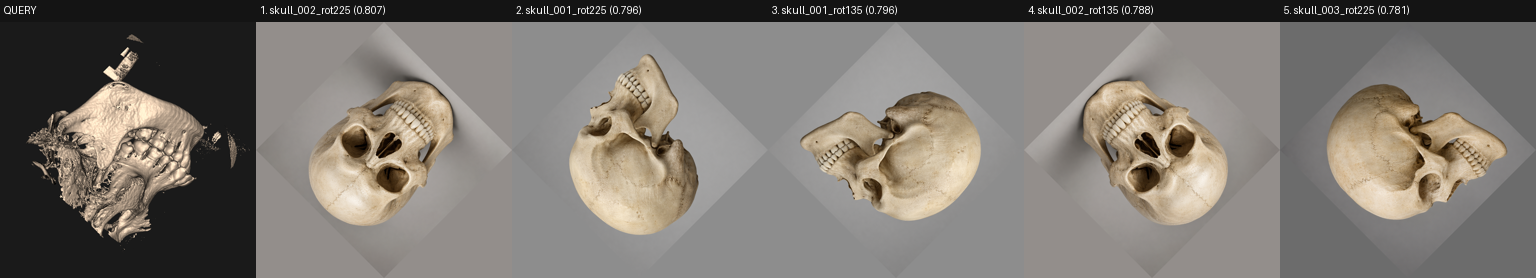

In [8]:
CANDIDATE_IMAGE_PATH = "../output/screenshots/blind_candidates/step_009/candidate_0qhlt.png"

result = image_matcher.match(CANDIDATE_IMAGE_PATH, top_k=5)
print(f"best_node_id: {result['best_node_id']}")
print(f"confidence_margin (top1 - top2): {result['confidence_margin']}  is_ambiguous: {result['is_ambiguous']}")
for m in result["top_matches"]:
    desc = node_descriptions.get(m["node_id"], "?")
    print(f"  {m['rank']}. {m['node_id']:<14s} sim={m['similarity']:.4f}  {desc}")

save_contact_sheet(CANDIDATE_IMAGE_PATH, result["top_matches"], "../output/candidate_vs_reference_contact_sheet.png")
display(Image("../output/candidate_vs_reference_contact_sheet.png"))